# Sentiment Analysis on Movie Reviews: TF-IDF with Random Forest, KNN, SVM and AdaBoost, benchmarked against a Pretrained DistilBERT

This notebook builds a sentiment classifier for the IMDB movie review dataset using a handful of classical ML models, then checks how those stack up against a pretrained transformer that's never seen this dataset before. It doesn't stop at binary positive/negative either. The second half pushes into multi-class emotion labels, just to see how far a bag-of-words approach can be stretched.

Short notes on TF-IDF, KNN, Random Forest, AdaBoost, SVM and DistilBERT sit right before each one gets used, so the notebook reads as a standalone walkthrough even without prior ML background.

The notebook covers:

1. Load and poke around the dataset
2. Clean up the review text
3. Turn text into TF-IDF features (unigrams and bigrams)
4. Train Random Forest, KNN, Linear SVM and AdaBoost, and compare bagging vs boosting
5. Run a pretrained DistilBERT with zero training
6. Score everything with accuracy, confusion matrices, ROC-AUC and 5-fold CV
7. Tune the one hyperparameter that matters most for each model
8. Swap polarity for seven emotion labels and classify those instead
9. Plot feature importances, SVM coefficients, word clouds, ROC curves
10. Wrap up with the theory behind why each model behaves the way it does

## 1. Setup

In [1]:
import re                                          # regex, used to strip HTML tags and non-letters during cleaning
import numpy as np                                 # numeric arrays, used for random seeding and vector math
import pandas as pd                                 # DataFrames, used to hold and slice the review dataset
import matplotlib.pyplot as plt                     # base plotting library for all the charts below
import seaborn as sns                               # sits on top of matplotlib, used here just for the confusion-matrix heatmaps

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold  # splitting data and running cross-validation
from sklearn.feature_extraction.text import TfidfVectorizer                             # turns cleaned text into TF-IDF numeric vectors
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier                 # the bagging model and the boosting model
from sklearn.neighbors import KNeighborsClassifier                                      # distance-based classifier
from sklearn.svm import LinearSVC                                                       # linear support vector machine, tuned for sparse high-dim text
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,   # accuracy, per-class error breakdown, and precision/recall/F1 report
    roc_auc_score, roc_curve, f1_score,                         # ranking quality (ROC-AUC) and the macro-F1 used later for emotion labels
)
from wordcloud import WordCloud                    # renders the positive/negative word-cloud images in Section 9

import nltk
nltk.download('stopwords', quiet=True)             # common words ("the", "and") to drop during cleaning
nltk.download('wordnet', quiet=True)                # lexical database that WordNetLemmatizer looks words up in
nltk.download('omw-1.4', quiet=True)                # multilingual data wordnet needs internally, English included
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer            # reduces words to their dictionary root ("loving" -> "love")

RANDOM_STATE = 42                                  # fixed seed so splits/shuffles are reproducible across runs
np.random.seed(RANDOM_STATE)

POS_LABEL = 'positive'
NEG_LABEL = 'negative'


## 2. Load the dataset

Reading straight from `IMDB Dataset.csv`, which lives in the same folder as this notebook.

In [2]:
import os

# Local dataset: 'IMDB Dataset.csv' sits in the same folder as this notebook.
DATA_PATH = "IMDB Dataset.csv"

# Fallback to the absolute path if the notebook is run from a different working directory.
if not os.path.exists(DATA_PATH):
    DATA_PATH = r"C:\Users\Acer\Desktop\new ai prinsiple project\IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


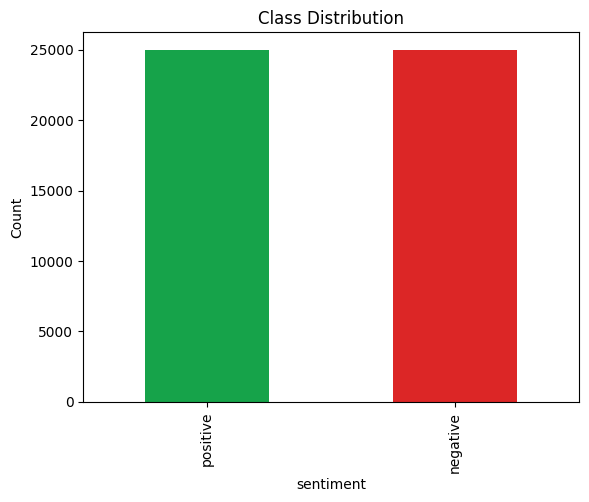

In [3]:
# Class balance check
print(df['sentiment'].value_counts())
df['sentiment'].value_counts().plot(kind='bar', color=['#16A34A', '#DC2626'])  # quick bar chart, green=positive, red=negative
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


## 3. Preprocessing

Standard text-cleaning pipeline here: strip out noise, lowercase everything, drop stopwords, and lemmatize so different forms of the same word ("loved", "loving", "loves") collapse down to one token. One thing specific to this dataset: the raw reviews are riddled with `<br /><br />` line breaks left over from the original scrape, so those need to go before anything else. Otherwise they show up in the vocabulary as junk tokens.

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)              # strip HTML tags (e.g. <br />)
    text = text.lower()                              # normalize case
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

# Run on the full set. ~50k reviews can take a few minutes on CPU; grab a coffee.
df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(3)

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode hooked...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...


Using a random 10,000-review subset instead of the full 50K set, mostly just to keep preprocessing and training times sane on a CPU.

In [5]:
df = df.sample(n=10000, random_state=RANDOM_STATE).reset_index(drop=True)  # take a random 10k-review subset to keep runtime sane
df['clean_review'] = df['review'].apply(clean_text)                        # re-clean just this subset (cheap, avoids reusing the full-set run)


## 4. Train/test split

In [6]:
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y   # stratify keeps the positive/negative ratio the same in both splits
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 8000 | Test size: 2000


### What is TF-IDF?

TF-IDF (Term Frequency-Inverse Document Frequency) is not a model, it is how this notebook turns review text into numbers. It scores each word by how often it appears in one review versus how common it is across all reviews, so distinctive words like "masterpiece" score high and filler words like "the" score near zero. Every classical model below trains on these TF-IDF vectors.

## 5. TF-IDF Feature Extraction (unigrams + bigrams)

This step turns the cleaned text into the numeric vectors every classical model below trains on. `max_features` caps the vocabulary at the top N most informative terms, which keeps things fast and stops the sparse matrix from getting out of hand.

I set `ngram_range=(1, 2)` here, so the vocabulary picks up two-word phrases alongside single words. Plain unigrams throw away word order completely: "not good" and "good" both collapse into the same token, "good". Bigrams let phrases like `not good`, `waste time` or `well worth` survive as their own features, which is exactly the kind of signal a plain bag-of-words model would otherwise miss. Since the budget is still capped at 5,000 features, unigrams and bigrams end up competing for the same slots, so only the bigrams that are actually common and useful make it in.

Everything from here through Section 9 runs on top of this new matrix.

In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))   # cap vocab at 5,000 terms; include single words and two-word phrases
X_train_tfidf = tfidf.fit_transform(X_train)                      # learn vocabulary + IDF weights from train, then vectorize train
X_test_tfidf = tfidf.transform(X_test)                            # reuse that same vocabulary/weights on test (never re-fit on test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

# How much of the 5,000-term budget did bigrams actually claim?
vocab = tfidf.get_feature_names_out()
n_bigrams = sum(1 for t in vocab if ' ' in t)                     # a bigram term contains a space, e.g. "not good"
print(f"Unigrams: {len(vocab) - n_bigrams} | Bigrams: {n_bigrams}")
print("Example bigrams kept:", [t for t in vocab if ' ' in t][:15])


TF-IDF matrix shape (train): (8000, 5000)
Unigrams: 4069 | Bigrams: 931
Example bigrams kept: ['absolutely nothing', 'academy award', 'act like', 'acting bad', 'acting good', 'acting great', 'acting talent', 'acting terrible', 'action film', 'action flick', 'action movie', 'action scene', 'action sequence', 'actor actress', 'actor film']


## 6. Train and Compare Models

Random Forest, KNN, a linear SVM and AdaBoost are all trained on the same TF-IDF vectors, so whatever accuracy gap shows up between them comes down to the algorithm, not the features.

`LinearSVC` is the SVM variant made for high-dimensional sparse data like this. It fits a linear boundary directly in the 5,000-dimensional term space instead of going through a kernel, which ends up both faster and usually more accurate on text than an RBF kernel would be.

`AdaBoostClassifier` is the boosting entry in the lineup. Random Forest and AdaBoost are both tree ensembles, but they combine trees for opposite reasons. Random Forest bags: it grows a few hundred deep trees independently on bootstrap samples and averages them out to cut down variance. AdaBoost boosts instead: it trains a chain of deliberately weak learners (depth-1 stumps, by default), each one re-weighted to focus on whatever its predecessor got wrong, which chips away at bias rather than variance. Section 20.5 gets into why that distinction actually matters on sparse text, and Section 16 sweeps the number of boosting rounds.

### What is KNN?

KNN (K-Nearest Neighbors) is a supervised classifier: it learns from reviews already labeled positive or negative. To label a new review, it finds the `k` most similar reviews by TF-IDF distance and goes with the majority label among them. Section 14 tunes `k`.

### What is Random Forest?

Random Forest is a supervised ensemble of many decision trees, each trained on a random sample of the data and features. Every tree votes positive or negative, and the forest goes with the majority, which averages out each tree's individual mistakes.

### What is AdaBoost?

AdaBoost (Adaptive Boosting) is a supervised ensemble too, but built differently from Random Forest. Instead of training trees in parallel, it trains simple stumps one at a time, each one focused on fixing the previous stump's mistakes. Section 20 compares this boosting approach to Random Forest's bagging.

### What is SVM?

SVM (Support Vector Machine, `LinearSVC` here) is a supervised classifier that finds the boundary line separating positive from negative reviews in TF-IDF space, picking the line with the widest margin on either side.

In [8]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (LinearSVC)": LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

results = {}
predictions = {}
scores = {}   # continuous score for the positive class, needed for ROC-AUC in Section 10

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    predictions[name] = pred

    # RF and KNN expose predict_proba; LinearSVC does not, so use its signed distance
    # from the hyperplane instead (see Section 10 for why that is valid for ROC-AUC).
    if hasattr(model, "predict_proba"):
        pos_col = list(model.classes_).index(POS_LABEL)
        scores[name] = model.predict_proba(X_test_tfidf)[:, pos_col]
    else:
        margin = model.decision_function(X_test_tfidf)
        # classes_ is sorted alphabetically -> ['negative', 'positive'], so a positive
        # margin already points at POS_LABEL. Flip it if that assumption ever changes.
        scores[name] = margin if model.classes_[1] == POS_LABEL else -margin

    print(f"{name:22s} accuracy = {acc:.4f}")

Random Forest          accuracy = 0.8380
KNN                    accuracy = 0.7145
SVM (LinearSVC)        accuracy = 0.8525
AdaBoost               accuracy = 0.7950


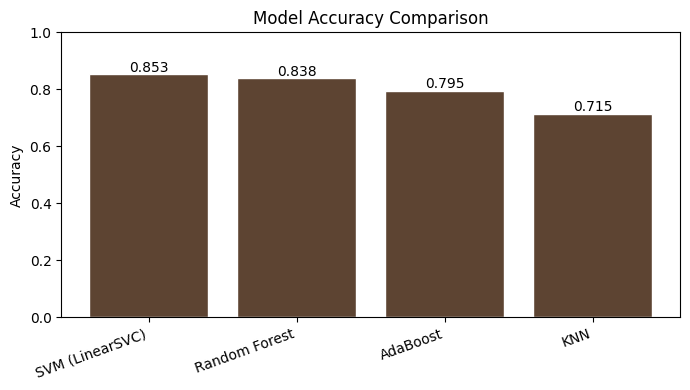

,Model,Accuracy
2,SVM (LinearSVC),0.8525
0,Random Forest,0.8380
3,AdaBoost,0.7950
1,KNN,0.7145


In [9]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df["Model"], results_df["Accuracy"], color="#5D4432", edgecolor="white")   # one bar per model, sorted best to worst
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")   # label each bar with its exact accuracy value
plt.tight_layout()
plt.show()

results_df


## 7. Evaluate Each Model in Detail

Confusion matrix and classification report for each model. Random Forest and KNN are the two named in the project title; SVM's in here as the model-selection extension.


=== Random Forest ===
              precision    recall  f1-score   support

    negative       0.83      0.85      0.84       992
    positive       0.85      0.83      0.84      1008

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



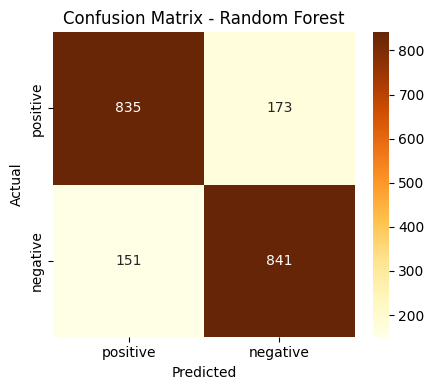


=== KNN ===
              precision    recall  f1-score   support

    negative       0.73      0.67      0.70       992
    positive       0.70      0.76      0.73      1008

    accuracy                           0.71      2000
   macro avg       0.72      0.71      0.71      2000
weighted avg       0.72      0.71      0.71      2000



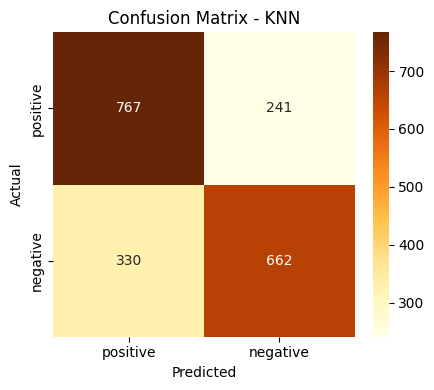


=== SVM (LinearSVC) ===
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85       992
    positive       0.84      0.87      0.86      1008

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



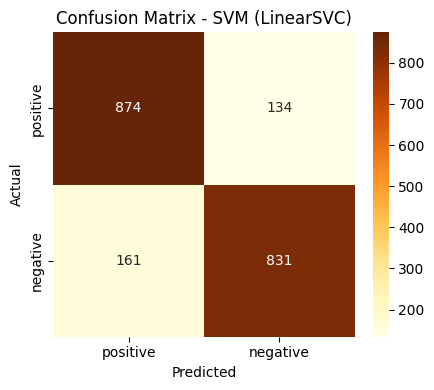


=== AdaBoost ===
              precision    recall  f1-score   support

    negative       0.83      0.73      0.78       992
    positive       0.77      0.86      0.81      1008

    accuracy                           0.80      2000
   macro avg       0.80      0.79      0.79      2000
weighted avg       0.80      0.80      0.79      2000



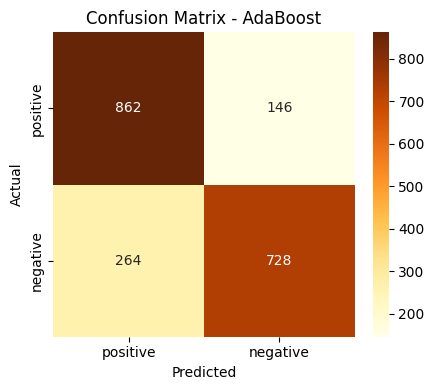

In [10]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred))               # precision, recall, F1 per class
    cm = confusion_matrix(y_true, y_pred, labels=[POS_LABEL, NEG_LABEL])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",         # seaborn heatmap: draws the confusion matrix as a colored grid with counts printed in each cell
                xticklabels=[POS_LABEL, NEG_LABEL],
                yticklabels=[POS_LABEL, NEG_LABEL], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

for name in models:
    evaluate_model(name, y_test, predictions[name])


## 8. What the Models Learned: RF Importance and SVM Coefficients

The "behind the scenes" part: which terms is each model actually leaning on? That's the direct answer to "why did it decide this," which is worth having for the report.

These are two different lenses on the same question. Random Forest importance is unsigned: it tells you a term was useful for splitting, but not which sentiment it points toward. SVM coefficients are signed, so they split cleanly into terms pushing toward positive and terms pushing toward negative. Check whether any two-word phrases, negations especially, show up in either list now that bigrams are in the vocabulary.

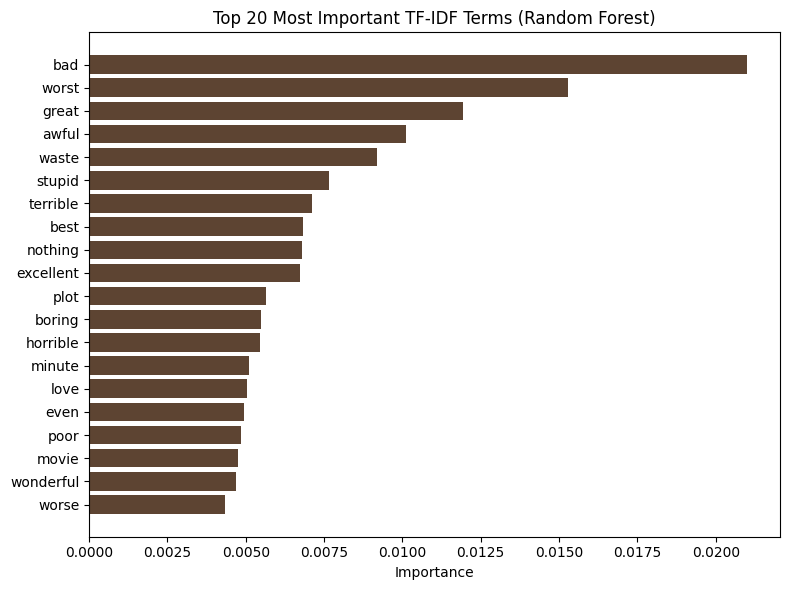

In [11]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_        # how much each TF-IDF term reduced impurity across all trees (unsigned)
feature_names = tfidf.get_feature_names_out()

top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]     # indices of the top-20 terms, highest importance first
top_features = pd.DataFrame({
    "term": feature_names[top_idx],
    "importance": importances[top_idx],
})

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features["term"][::-1], top_features["importance"][::-1], color="#5D4432")   # reversed so the biggest bar is on top
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} Most Important TF-IDF Terms (Random Forest)")
plt.tight_layout()
plt.show()


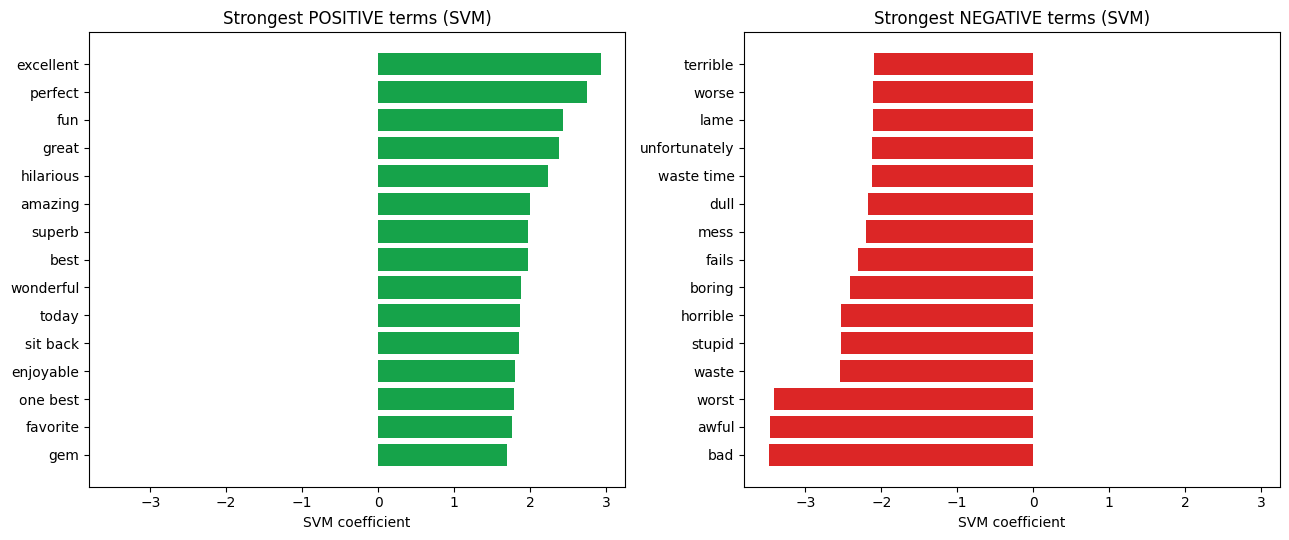

Bigrams among the top SVM terms: ['one best', 'sit back', 'waste time']


In [12]:
svm_model = models["SVM (LinearSVC)"]
coefs = svm_model.coef_[0]                          # one signed weight per TF-IDF term (unlike RF importance, sign tells direction)
# classes_ is ['negative', 'positive'], so a positive coefficient argues for 'positive'.
if svm_model.classes_[1] != POS_LABEL:
    coefs = -coefs

order = np.argsort(coefs)                           # ascending: most negative first, most positive last
top_pos = pd.DataFrame({"term": feature_names[order[-15:]], "coef": coefs[order[-15:]]})
top_neg = pd.DataFrame({"term": feature_names[order[:15]], "coef": coefs[order[:15]]})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
axes[0].barh(top_pos["term"], top_pos["coef"], color="#16A34A")
axes[0].set_title("Strongest POSITIVE terms (SVM)")
axes[1].barh(top_neg["term"], top_neg["coef"], color="#DC2626")
axes[1].set_title("Strongest NEGATIVE terms (SVM)")
for ax in axes:
    ax.set_xlabel("SVM coefficient")
plt.tight_layout()
plt.show()

bigram_hits = [t for t in list(top_pos["term"]) + list(top_neg["term"]) if ' ' in t]   # check whether any two-word phrase made the top list
print("Bigrams among the top SVM terms:", bigram_hits if bigram_hits else "none")


## 9. Word Clouds: Positive vs Negative

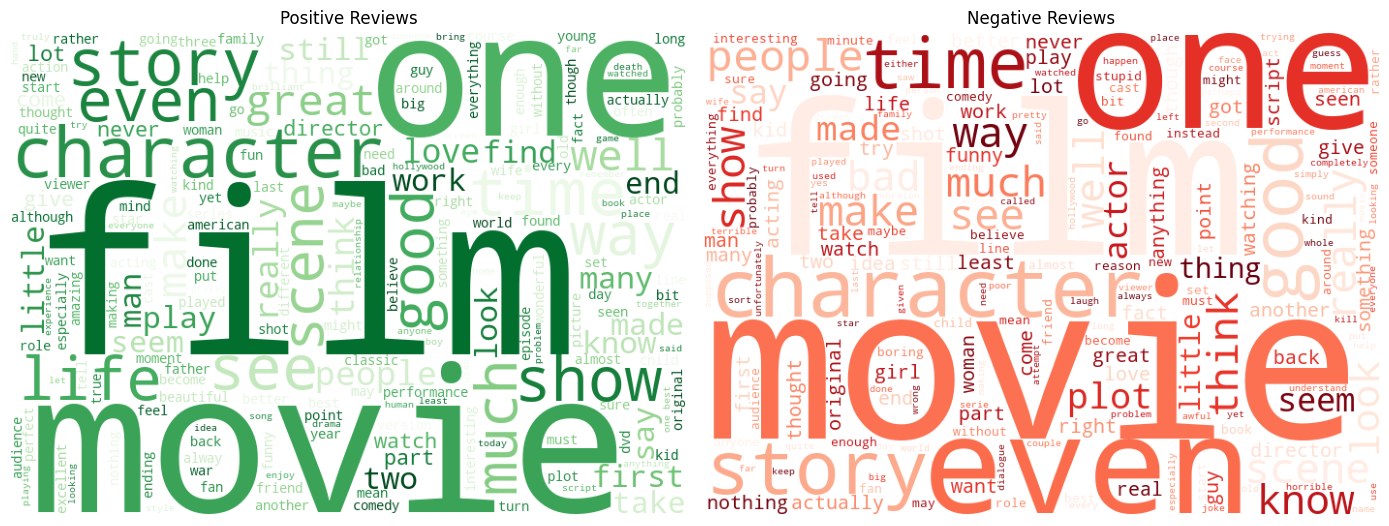

In [13]:
pos_text = " ".join(df.loc[df['sentiment'] == 'positive', 'clean_review'])   # all positive reviews concatenated into one blob of text
neg_text = " ".join(df.loc[df['sentiment'] == 'negative', 'clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_pos = WordCloud(width=700, height=500, background_color="white", colormap="Greens").generate(pos_text)   # sizes each word by how often it appears
axes[0].imshow(wc_pos)
axes[0].axis("off")
axes[0].set_title("Positive Reviews")

wc_neg = WordCloud(width=700, height=500, background_color="white", colormap="Reds").generate(neg_text)
axes[1].imshow(wc_neg)
axes[1].axis("off")
axes[1].set_title("Negative Reviews")

plt.tight_layout()
plt.show()


## 10. ROC-AUC

Accuracy only tells you how often the model got it right at its default cutoff. ROC-AUC measures how well a model ranks positive reviews above negative ones across every threshold: 0.5 is random, 1.0 is perfect separation.

- **Random Forest**: `predict_proba` (fraction of trees voting positive) plays nicely with ROC.
- **SVM (LinearSVC)**: no `predict_proba`, so we use `decision_function` (signed distance from the hyperplane) instead. ROC-AUC only cares about ranking, so this works fine.
- **KNN**: `predict_proba` with k=5 can only take 6 possible values, so its ROC curve is a coarse staircase and its AUC isn't really comparable to the others. A bigger k gives a finer score (see Section 14).


Random Forest          ROC-AUC = 0.9169  (177 distinct scores)
KNN                    ROC-AUC = 0.7723  (6 distinct scores)
SVM (LinearSVC)        ROC-AUC = 0.9326  (2000 distinct scores)
AdaBoost               ROC-AUC = 0.8774  (1862 distinct scores)


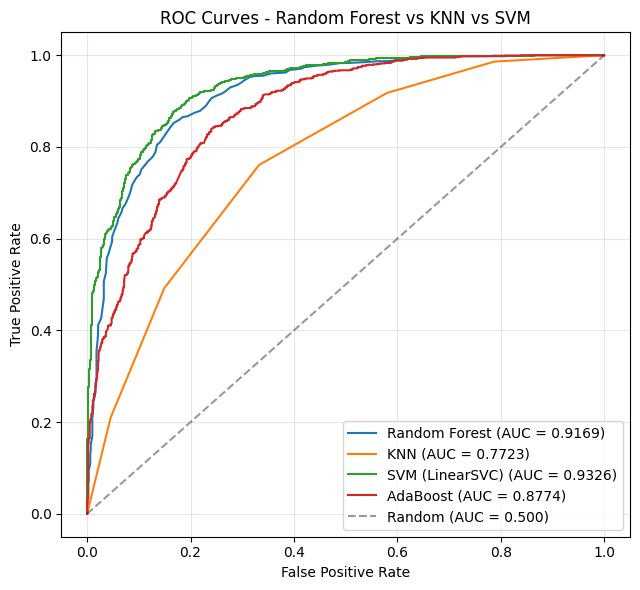


KNN produced only 6 distinct scores (k=5 -> at most k+1), hence the staircase curve.


In [14]:
y_test_bin = (y_test == POS_LABEL).astype(int)      # roc_auc_score needs 0/1 labels, not strings

auc_results = {}
fig, ax = plt.subplots(figsize=(6.5, 6))

for name in models:
    auc = roc_auc_score(y_test_bin, scores[name])       # scores[name] is the continuous score computed back in Section 6
    auc_results[name] = auc
    fpr, tpr, _ = roc_curve(y_test_bin, scores[name])    # false-positive rate and true-positive rate at every possible threshold
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
    print(f"{name:22s} ROC-AUC = {auc:.4f}  ({len(np.unique(scores[name]))} distinct scores)")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random (AUC = 0.500)")   # diagonal = a coin-flip classifier, for reference
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Random Forest vs KNN vs SVM")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKNN produced only {len(np.unique(scores['KNN']))} distinct scores "
      f"(k={models['KNN'].n_neighbors} -> at most k+1), hence the staircase curve.")


**Quick read for slides:** the ROC curve plots true-positive rate against false-positive rate at every possible score cutoff, not just the default 0.5 threshold. A curve hugging the top-left corner separates positive and negative reviews well; a curve near the diagonal guesses at random. SVM's curve sits highest (AUC 0.93), Random Forest follows close behind (AUC 0.92), AdaBoost trails further (AUC 0.88), and KNN's curve looks like a staircase because its scores only take 6 distinct values (AUC 0.77).

## 11. Cross-Validation (5-fold)

A single train/test split is one roll of the dice: a lucky or unlucky split can swing accuracy by a percent or two, enough to flip which model looks best. 5-fold CV splits the training set into five chunks, trains on four and validates on the fifth, five times over, then reports the mean and standard deviation. That std is the important half: if two models are 1.5% apart but each has a std of 1.2%, that gap is noise.

One caveat: `X_train_tfidf` was fit on the whole training set before the folds got cut, so each fold's validation slice technically had a hand in the IDF weights and vocabulary. That's a mild optimistic bias. The cell below shows both the quick version and a leak-free `Pipeline` version that refits the vectorizer inside each fold, so you can check the two numbers land close together and the shortcut didn't skew anything.

Random Forest          CV accuracy = 0.8476 +/- 0.0138   folds: [0.8706 0.8438 0.8344 0.8344 0.855 ]
KNN                    CV accuracy = 0.7186 +/- 0.0116   folds: [0.725  0.7075 0.7381 0.7081 0.7144]
SVM (LinearSVC)        CV accuracy = 0.8623 +/- 0.0112   folds: [0.8738 0.8756 0.8512 0.8481 0.8625]
AdaBoost               CV accuracy = 0.8019 +/- 0.0150   folds: [0.825  0.8069 0.7825 0.7887 0.8062]


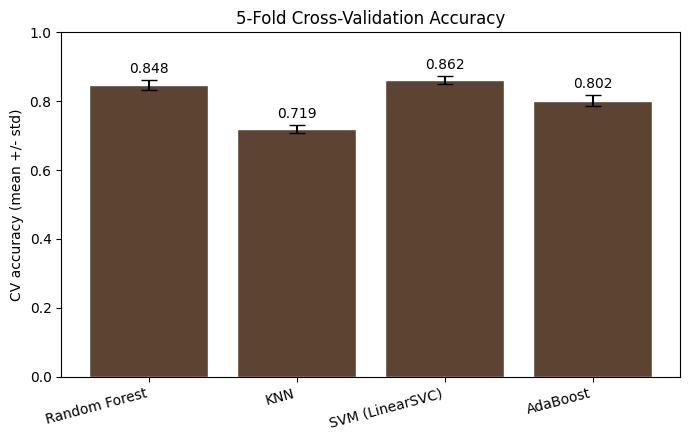

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # 5 folds, each keeping the class ratio, shuffled once up front
cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='accuracy', n_jobs=-1)  # trains/evaluates 5 times, once per fold
    cv_results[name] = cv_scores
    print(f"{name:22s} CV accuracy = {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}   "
          f"folds: {np.round(cv_scores, 4)}")

fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(cv_results)
means = [cv_results[n].mean() for n in names]
stds = [cv_results[n].std() for n in names]
ax.bar(names, means, yerr=stds, capsize=6, color="#5D4432", edgecolor="white")   # error bars show the std across the 5 folds
ax.set_ylabel("CV accuracy (mean +/- std)")
ax.set_title("5-Fold Cross-Validation Accuracy")
ax.set_ylim(0, 1)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


In [16]:
# Leak-free comparison: the vectorizer is refitted inside each fold.
from sklearn.pipeline import Pipeline

print("Leak-free CV (TF-IDF refitted per fold) - compare against the numbers above:\n")
for name, model in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("clf", model.__class__(**model.get_params())),
    ])
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    delta = s.mean() - cv_results[name].mean()
    print(f"{name:22s} CV accuracy = {s.mean():.4f} +/- {s.std():.4f}   (delta vs. leaky: {delta:+.4f})")

Leak-free CV (TF-IDF refitted per fold) - compare against the numbers above:

Random Forest          CV accuracy = 0.8435 +/- 0.0133   (delta vs. leaky: -0.0041)
KNN                    CV accuracy = 0.7151 +/- 0.0130   (delta vs. leaky: -0.0035)
SVM (LinearSVC)        CV accuracy = 0.8618 +/- 0.0087   (delta vs. leaky: -0.0005)
AdaBoost               CV accuracy = 0.7998 +/- 0.0156   (delta vs. leaky: -0.0021)


### What is DistilBERT?

DistilBERT is a distilled (smaller, faster) version of BERT (Bidirectional Encoder Representations from Transformers), a pretrained transformer that already learned sentiment from a huge text corpus before this notebook ran. It gets zero training here, just predictions, making it a fair zero-shot benchmark against the models trained from scratch above.

## 12. DistilBERT Pretrained, No Training Required

Everything up to this point treats a review as a bag of terms. TF-IDF counts what words show up and how rare they are, but never sees what order they came in (bigrams recover a sliver of that, nothing more). DistilBERT works completely differently: it's a transformer that reads the review as a sequence and builds a representation of each word based on the words around it.

The checkpoint used here, `distilbert-base-uncased-finetuned-sst-2-english`, is already fine-tuned on the Stanford Sentiment Treebank, so there's no training step at all in this notebook; just download the weights and run inference on the same test reviews. That makes it a genuine zero-shot baseline: it's never seen a single review from our training set.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running DistilBERT on: CPU


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5477.38it/s]


Scoring 500 reviews...

DistilBERT accuracy = 0.8920 | ROC-AUC = 0.9601  (zero training)

=== DistilBERT (pretrained) ===
              precision    recall  f1-score   support

    negative       0.88      0.91      0.90       258
    positive       0.91      0.87      0.89       242

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



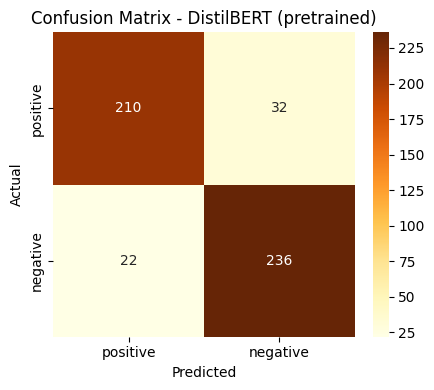

In [17]:
# Colab already ships transformers + torch. Uncomment locally if the import fails.
# !pip install -q transformers torch

import torch
from transformers import pipeline as hf_pipeline

DISTILBERT_N = 500          # set to None to score the full 2,000-review test set (slow on CPU)
DEVICE = 0 if torch.cuda.is_available() else -1
print("Running DistilBERT on:", "GPU" if DEVICE == 0 else "CPU")

sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=DEVICE,
    truncation=True,
    max_length=512,
)

# Pick the evaluation subset and remember where those rows sit in the test set,
# so the classical models can be scored on exactly the same reviews.
if DISTILBERT_N is None:
    bert_idx = X_test.index
else:
    bert_idx = X_test.sample(DISTILBERT_N, random_state=RANDOM_STATE).index

pos_in_test = np.array([X_test.index.get_loc(i) for i in bert_idx])
raw_reviews = df.loc[bert_idx, 'review'].tolist()   # RAW text, not clean_review
y_bert_true = y_test.loc[bert_idx]

print(f"Scoring {len(raw_reviews)} reviews...")
raw_out = sentiment_pipe(raw_reviews, batch_size=16)

bert_pred = np.array([POS_LABEL if o['label'] == 'POSITIVE' else NEG_LABEL for o in raw_out])
# P(positive): the pipeline reports the confidence of the winning label, so flip it for negatives.
bert_score = np.array([o['score'] if o['label'] == 'POSITIVE' else 1 - o['score'] for o in raw_out])

bert_acc = accuracy_score(y_bert_true, bert_pred)
bert_auc = roc_auc_score((y_bert_true == POS_LABEL).astype(int), bert_score)
print(f"\nDistilBERT accuracy = {bert_acc:.4f} | ROC-AUC = {bert_auc:.4f}  (zero training)")

evaluate_model("DistilBERT (pretrained)", y_bert_true, bert_pred)

## 13. Final Model Comparison: RF vs KNN vs SVM vs AdaBoost vs DistilBERT

This table is the headline result. Since DistilBERT might have been scored on a subsample, the classical models get rescored on that same subset too, in the "Accuracy (same subset)" column. That's the actually fair comparison, not the full-test column. Cross-validation numbers only exist for the three trained models; DistilBERT never gets trained here, so there's nothing to cross-validate.

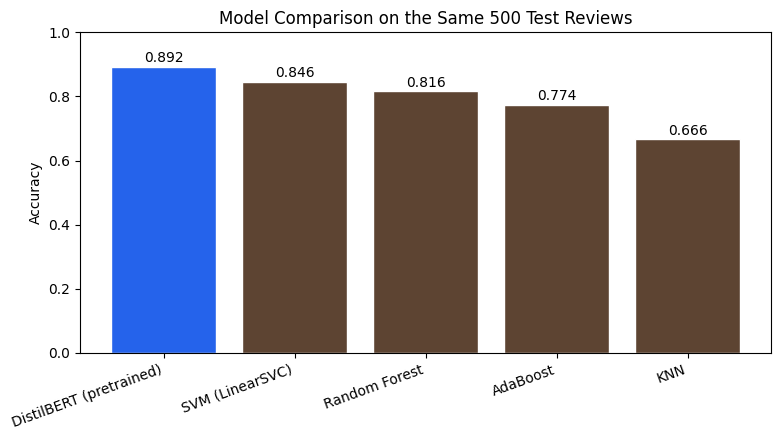

,Model,Accuracy (full test),Accuracy (same subset),ROC-AUC (full test),CV mean,CV std,Trained here?
0,DistilBERT (pretrained),NaN,0.892,NaN,NaN,NaN,no (zero-shot)
1,SVM (LinearSVC),0.8525,0.846,0.9326,0.8622,0.0112,yes
2,Random Forest,0.8380,0.816,0.9169,0.8476,0.0138,yes
3,AdaBoost,0.7950,0.774,0.8774,0.8019,0.0150,yes
4,KNN,0.7145,0.666,0.7723,0.7186,0.0116,yes


In [18]:
rows = []
for name in models:
    subset_acc = accuracy_score(y_bert_true, np.asarray(predictions[name])[pos_in_test])   # rescore each classical model on DistilBERT's subset
    rows.append({
        "Model": name,
        "Accuracy (full test)": results[name],
        "Accuracy (same subset)": subset_acc,
        "ROC-AUC (full test)": auc_results[name],
        "CV mean": cv_results[name].mean(),
        "CV std": cv_results[name].std(),
        "Trained here?": "yes",
    })

rows.append({
    "Model": "DistilBERT (pretrained)",
    "Accuracy (full test)": np.nan,          # never scored on the full test set, only the subsample
    "Accuracy (same subset)": bert_acc,
    "ROC-AUC (full test)": np.nan,
    "CV mean": np.nan,                       # never trained, so cross-validation doesn't apply
    "CV std": np.nan,
    "Trained here?": "no (zero-shot)",
})

final_results = pd.DataFrame(rows).sort_values("Accuracy (same subset)", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#2563EB" if m.startswith("DistilBERT") else "#5D4432" for m in final_results["Model"]]   # highlight DistilBERT's bar in blue
ax.bar(final_results["Model"], final_results["Accuracy (same subset)"], color=colors, edgecolor="white")
ax.set_ylabel("Accuracy")
ax.set_title(f"Model Comparison on the Same {len(bert_idx)} Test Reviews")
ax.set_ylim(0, 1)
for i, v in enumerate(final_results["Accuracy (same subset)"]):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

final_results.round(4)


**Ranking for the presentation:** DistilBERT tops the shared 500-review subset at 89.20% with zero training, since it already learned sentiment from a much larger corpus. Among the models trained here, SVM comes next at 85.25% accuracy on the full test set, Random Forest follows at 83.80%, AdaBoost sits at 79.50%, and KNN finishes last at 71.45% because TF-IDF vectors are too high-dimensional for distance-based methods to work well. Order: DistilBERT > SVM > Random Forest > AdaBoost > KNN.

## 14. KNN Tuning: Why KNN Struggles on TF-IDF

TF-IDF vectors are high-dimensional and sparse, and adding bigrams in Section 5 didn't change that. It's still a 5,000-dimensional space where most entries are zero. KNN leans entirely on distance between points, and distance stops meaning much as dimensionality climbs (the "curse of dimensionality"), so it's not surprising that KNN trails both Random Forest and SVM here. This cell sweeps `n_neighbors` to show exactly that, and it's a good one to quote directly when explaining the accuracy gap.

There's a second payoff to a bigger k, mentioned back in Section 10: `predict_proba` for KNN can only take k+1 distinct values, so raising k also gives a finer-grained score and a less broken-looking ROC curve.

k= 3  accuracy=0.6995
k= 5  accuracy=0.7145
k= 7  accuracy=0.7330
k= 9  accuracy=0.7380
k=11  accuracy=0.7455
k=15  accuracy=0.7575


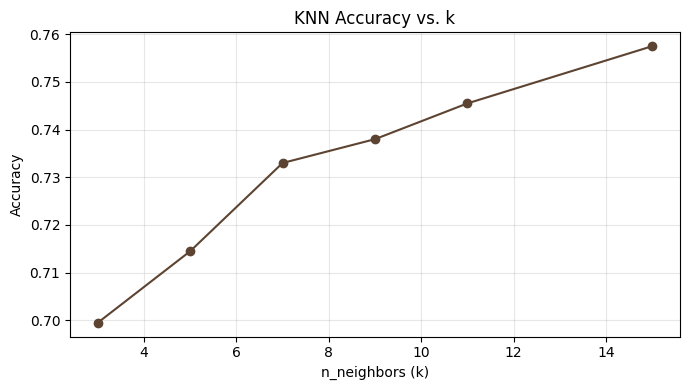

In [19]:
k_values = [3, 5, 7, 9, 11, 15]        # candidate values for KNN's n_neighbors
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_tfidf))
    k_scores.append(acc)
    print(f"k={k:2d}  accuracy={acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, k_scores, marker='o', color="#5D4432")   # line plot: accuracy as k increases
ax.set_xlabel("n_neighbors (k)")
ax.set_ylabel("Accuracy")
ax.set_title("KNN Accuracy vs. k")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Random Forest Tuning: n_estimators

Same logic for Random Forest: plotting accuracy against number of trees, so the value used back in Section 6 is backed by something rather than just picked.

n_estimators= 50  accuracy=0.8190
n_estimators=100  accuracy=0.8325
n_estimators=200  accuracy=0.8380
n_estimators=300  accuracy=0.8420


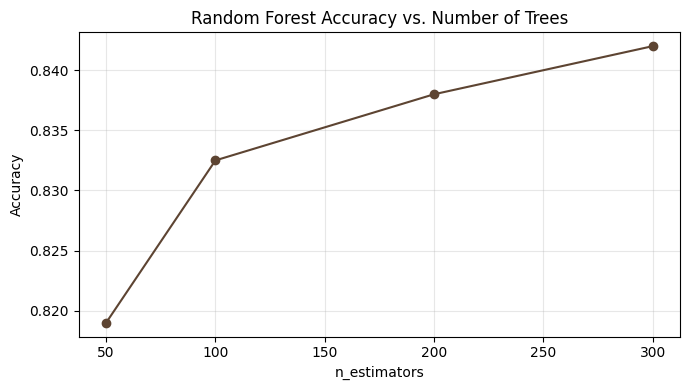

In [20]:
n_estimators_values = [50, 100, 200, 300]   # candidate tree counts for Random Forest
rf_scores = []

for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test_tfidf))
    rf_scores.append(acc)
    print(f"n_estimators={n:3d}  accuracy={acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_estimators_values, rf_scores, marker='o', color="#5D4432")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.set_title("Random Forest Accuracy vs. Number of Trees")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 16. AdaBoost Tuning - Number of Boosting Rounds

Same hyperparameter-justification treatment as KNN and Random Forest, and honestly the most interesting of the three. Since every AdaBoost round only adds a depth-1 stump, a single yes/no check on one term, and the ensemble starts out badly underfit and keeps climbing as rounds pile up. If accuracy is still rising at the far right of this plot, that's a sign AdaBoost is bias-limited here rather than variance-limited, which is the opposite failure mode from Random Forest, and exactly the point made in Section 20.5.

The cost: boosting is inherently sequential: round t needs round t-1's errors, so unlike Random Forest it can't be parallelized across trees with `n_jobs`.

n_estimators= 50  accuracy=0.7370
n_estimators=100  accuracy=0.7610
n_estimators=200  accuracy=0.7950
n_estimators=300  accuracy=0.8050


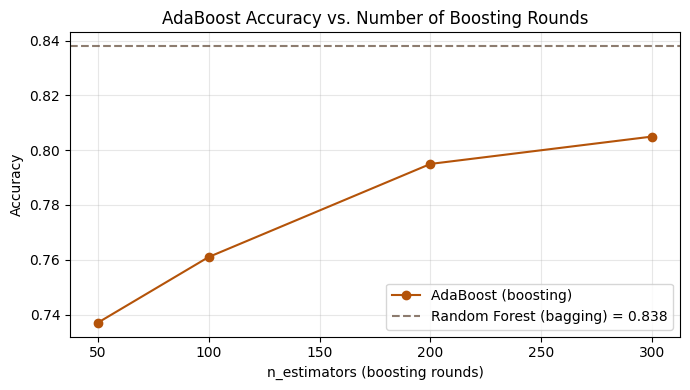


Accuracy still rising at the last point -> AdaBoost is bias-limited here; more rounds would help.


In [21]:
ada_rounds = [50, 100, 200, 300]      # candidate boosting-round counts for AdaBoost
ada_scores = []

for n in ada_rounds:
    ada = AdaBoostClassifier(n_estimators=n, random_state=RANDOM_STATE)
    ada.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, ada.predict(X_test_tfidf))
    ada_scores.append(acc)
    print(f"n_estimators={n:3d}  accuracy={acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ada_rounds, ada_scores, marker='o', color="#B45309", label="AdaBoost (boosting)")
ax.axhline(results["Random Forest"], ls='--', color="#5D4432", alpha=0.7,   # flat reference line for Random Forest's own accuracy
           label=f"Random Forest (bagging) = {results['Random Forest']:.3f}")
ax.set_xlabel("n_estimators (boosting rounds)")
ax.set_ylabel("Accuracy")
ax.set_title("AdaBoost Accuracy vs. Number of Boosting Rounds")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if ada_scores[-1] == max(ada_scores):
    print("\nAccuracy still rising at the last point -> AdaBoost is bias-limited here; more rounds would help.")


## 17. Sample Predictions

A handful of individual reviews with actual vs. predicted labels across every model, useful for a "here it is working live" demo, and for spotting the kinds of reviews each model trips over. Worth specifically looking for rows where DistilBERT gets it right and the TF-IDF models don't; those tend to be negation ("not bad," "never boring"), sarcasm, or mixed reviews where the verdict hinges on word order, and they're the strongest concrete evidence for the argument in Section 20.

In [22]:
# Sample from the reviews DistilBERT actually scored, so every column is filled in.
sample_idx = pd.Index(bert_idx).to_series().sample(10, random_state=RANDOM_STATE).values
sample_pos = np.array([X_test.index.get_loc(i) for i in sample_idx])   # map back to positions in the test set

sample_df = pd.DataFrame({
    "review": df.loc[sample_idx, "review"].str.slice(0, 120) + "...",   # truncate for display only
    "actual": y_test.loc[sample_idx],
})
for name in models:
    sample_df[name] = np.asarray(predictions[name])[sample_pos]

if bert_pred is not None:
    sample_df["DistilBERT"] = pd.Series(bert_pred, index=bert_idx).loc[sample_idx].values

sample_df


,review,actual,Random Forest,KNN,SVM (LinearSVC),AdaBoost,DistilBERT
7490,I don't remember seeing another murder/mystery...,negative,negative,negative,negative,negative,negative
6958,Jason Lee's pecks are back! If that's what you...,negative,negative,negative,negative,negative,negative
6236,I picked up this movie with the intention of g...,negative,negative,negative,negative,negative,negative
1660,Recently had the pleasure of seeing this emoti...,positive,positive,negative,positive,positive,positive
9425,"OK, so one night me and some friends decided t...",negative,negative,negative,negative,negative,negative
8361,Let me set the scene. It is the school holiday...,positive,negative,negative,positive,positive,positive
8878,I´ve seen this at the Fantasy Filmfest in Colo...,negative,negative,negative,negative,negative,negative
6000,I don't know how and where do the Iranian dire...,positive,positive,positive,positive,positive,positive
1361,What a great show! A very underrated dramatic ...,positive,positive,positive,positive,positive,positive
4636,"""The Kite Runner"" is one of the most controver...",positive,positive,positive,positive,positive,positive


## 18. Emotion Labels: Going Beyond Positive/Negative

"This film made me furious" and "this film bored me to tears" are both negative, but not the same reaction. IMDB has no emotion annotation, so labels here are generated with `j-hartmann/emotion-english-distilroberta-base`; silver labels standing in for human ones, tagging each review as one of seven emotions (anger, disgust, fear, joy, neutral, sadness, surprise).

This measures whether TF-IDF can reproduce a transformer's emotion judgments, not whether it detects real human emotion. Class imbalance is also severe (disgust/neutral/joy dominate), which is why Section 19 reports macro-F1 alongside accuracy. Labelling takes ~0.57s/review on CPU, so results are cached to `emotion_labels.csv`; delete that file to force a relabel.


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 10502.76it/s]


Labelling 3000 reviews on CPU (~28 min on CPU)...
Saved to emotion_labels.csv.

Emotion distribution:
emotion
disgust     813
neutral     665
joy         465
sadness     390
fear        315
surprise    247
anger       105

Majority class 'disgust' is 27.1% of the data - that is the accuracy floor any model must beat.


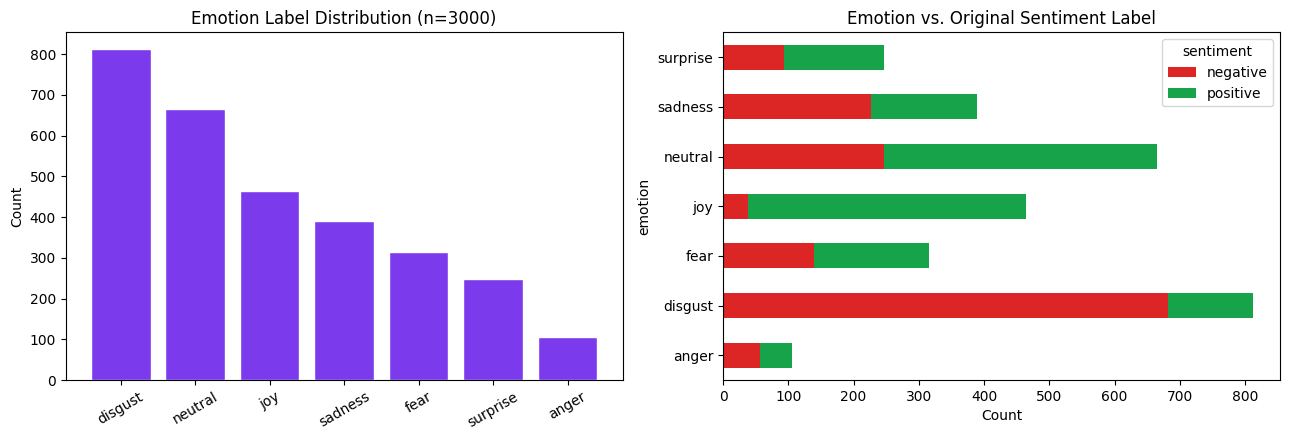


Emotion vs sentiment cross-tab:
sentiment  negative  positive
emotion                      
anger            57        48
disgust         682       131
fear            139       176
joy              39       426
neutral         247       418
sadness         227       163
surprise         93       154


In [23]:
import os

EMOTION_N = 3000                                   # reviews to label; ~0.57s each on CPU
EMOTION_MODEL = "j-hartmann/emotion-english-distilroberta-base"
EMOTION_CACHE = "emotion_labels.csv"

emo_idx = df.sample(EMOTION_N, random_state=RANDOM_STATE).index
emotion_ready = False

# Reuse cached labels when they cover exactly the reviews we want.
if os.path.exists(EMOTION_CACHE):
    cached = pd.read_csv(EMOTION_CACHE, index_col=0)
    if set(emo_idx).issubset(cached.index):
        emotion_labels = cached.loc[emo_idx, "emotion"]
        emotion_ready = True
        print(f"Loaded {len(emotion_labels)} cached labels from {EMOTION_CACHE} (delete it to relabel).")
    else:
        print(f"{EMOTION_CACHE} does not cover the current sample - relabelling.")

if not emotion_ready:
    try:
        import torch
        from transformers import pipeline as hf_pipeline
    except ImportError:
        print("transformers / torch not installed - skipping the emotion track.")
        print("To enable Sections 18-19:  pip install transformers torch")
    else:
        dev = 0 if torch.cuda.is_available() else -1
        emo_pipe = hf_pipeline("text-classification", model=EMOTION_MODEL, device=dev,
                               truncation=True, max_length=512)
        print(f"Labelling {EMOTION_N} reviews on {'GPU' if dev == 0 else 'CPU'} "
              f"(~{EMOTION_N * 0.57 / 60:.0f} min on CPU)...")
        out = emo_pipe(df.loc[emo_idx, 'review'].tolist(), batch_size=16)   # RAW text again
        emotion_labels = pd.Series([o['label'] for o in out], index=emo_idx, name="emotion")
        pd.DataFrame({"emotion": emotion_labels,
                      "score": [o['score'] for o in out]}).to_csv(EMOTION_CACHE)
        emotion_ready = True
        print(f"Saved to {EMOTION_CACHE}.")

if emotion_ready:
    counts = emotion_labels.value_counts()
    print("\nEmotion distribution:")
    print(counts.to_string())
    print(f"\nMajority class '{counts.index[0]}' is {counts.iloc[0] / len(emotion_labels):.1%} "
          f"of the data - that is the accuracy floor any model must beat.")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(counts.index, counts.values, color="#7C3AED", edgecolor="white")
    axes[0].set_title(f"Emotion Label Distribution (n={len(emotion_labels)})")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=30)

    # How the seven emotions line up against the original binary sentiment.
    cross = pd.crosstab(emotion_labels, df.loc[emo_idx, 'sentiment'])
    cross.plot(kind="barh", stacked=True, ax=axes[1],
               color={"positive": "#16A34A", "negative": "#DC2626"})
    axes[1].set_title("Emotion vs. Original Sentiment Label")
    axes[1].set_xlabel("Count")
    plt.tight_layout()
    plt.show()

    print("\nEmotion vs sentiment cross-tab:")
    print(cross.to_string())

## 19. Emotion Classification with TF-IDF

Same pipeline as Sections 5-7, just with seven emotions as the target instead of two polarities. Every classifier here handles multi-class natively: `LinearSVC` fits one-vs-rest, AdaBoost uses SAMME, Random Forest and KNN vote across classes, so really the only changes are the label column and a refitted vectorizer (the emotion subset is a different slice of reviews, so its vocabulary and IDF weights differ too).

DistilBERT is deliberately left out of this comparison. The emotion model produced these labels in the first place, so scoring it against them would return something close to 100% by construction and mean nothing. That would just be circular.

Read macro-F1 here, not accuracy. With one class holding a big chunk of the data, a model that just predicts the majority label everywhere scores well on accuracy while being completely useless. Macro-F1 averages the F1 score across classes equally, so a rare emotion the model never predicts drags the number down. The majority-class baseline printed below is the number accuracy actually has to beat to mean anything.

In [24]:
if not emotion_ready:
    print("Emotion labels unavailable - run Section 18 first.")
else:
    # Drop classes too rare to split or evaluate, and say exactly which (no silent truncation).
    MIN_PER_CLASS = 10
    vc = emotion_labels.value_counts()
    keep = vc[vc >= MIN_PER_CLASS].index
    dropped = vc[vc < MIN_PER_CLASS]
    if len(dropped):
        print(f"Dropped {len(dropped)} class(es) with fewer than {MIN_PER_CLASS} examples: "
              f"{dropped.to_dict()}")

    mask = emotion_labels.isin(keep)
    emo_text = df.loc[emotion_labels.index[mask], 'clean_review']
    y_emo = emotion_labels[mask]
    print(f"Using {len(y_emo)} reviews across {len(keep)} emotions: {sorted(keep)}\n")

    Xe_train, Xe_test, ye_train, ye_test = train_test_split(
        emo_text, y_emo, test_size=0.2, random_state=RANDOM_STATE, stratify=y_emo)

    tfidf_emo = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))   # separate vectorizer: this subset has its own vocabulary/IDF weights
    Xe_train_tfidf = tfidf_emo.fit_transform(Xe_train)
    Xe_test_tfidf = tfidf_emo.transform(Xe_test)
    print("Emotion TF-IDF matrix (train):", Xe_train_tfidf.shape)

    baseline = ye_test.value_counts().iloc[0] / len(ye_test)   # accuracy of just always guessing the most common emotion
    print(f"Majority-class baseline accuracy: {baseline:.4f}\n")

    emo_results = {}
    emo_predictions = {}

    for name, proto in models.items():
        m = proto.__class__(**proto.get_params())      # fresh, unfitted copy (the originals are already fit for binary sentiment)
        m.fit(Xe_train_tfidf, ye_train)
        pred = m.predict(Xe_test_tfidf)
        emo_predictions[name] = pred
        emo_results[name] = {
            "Accuracy": accuracy_score(ye_test, pred),
            "Macro F1": f1_score(ye_test, pred, average='macro'),       # unweighted mean across classes, punishes ignoring rare emotions
            "Weighted F1": f1_score(ye_test, pred, average='weighted'), # mean weighted by class size, closer to plain accuracy
        }
        print(f"{name:22s} acc={emo_results[name]['Accuracy']:.4f}  "
              f"macro-F1={emo_results[name]['Macro F1']:.4f}  "
              f"weighted-F1={emo_results[name]['Weighted F1']:.4f}")

    emo_df = pd.DataFrame(emo_results).T.sort_values("Macro F1", ascending=False)


Using 3000 reviews across 7 emotions: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

Emotion TF-IDF matrix (train): (2400, 5000)
Majority-class baseline accuracy: 0.2717

Random Forest          acc=0.4983  macro-F1=0.3627  weighted-F1=0.4545
KNN                    acc=0.3233  macro-F1=0.2048  weighted-F1=0.2833
SVM (LinearSVC)        acc=0.4417  macro-F1=0.3341  weighted-F1=0.4207
AdaBoost               acc=0.4350  macro-F1=0.3146  weighted-F1=0.3847


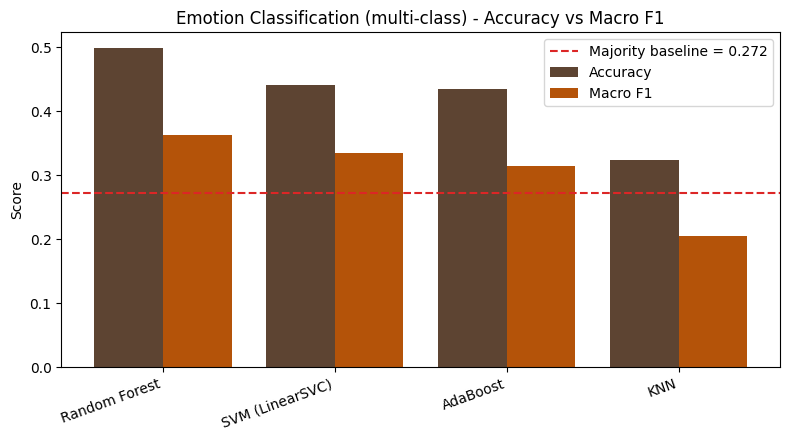

=== Random Forest - per-class breakdown ===
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        21
     disgust       0.54      0.77      0.63       163
        fear       0.77      0.27      0.40        63
         joy       0.56      0.63      0.60        93
     neutral       0.38      0.62      0.47       133
     sadness       0.80      0.10      0.18        78
    surprise       0.67      0.16      0.26        49

    accuracy                           0.50       600
   macro avg       0.53      0.36      0.36       600
weighted avg       0.56      0.50      0.45       600



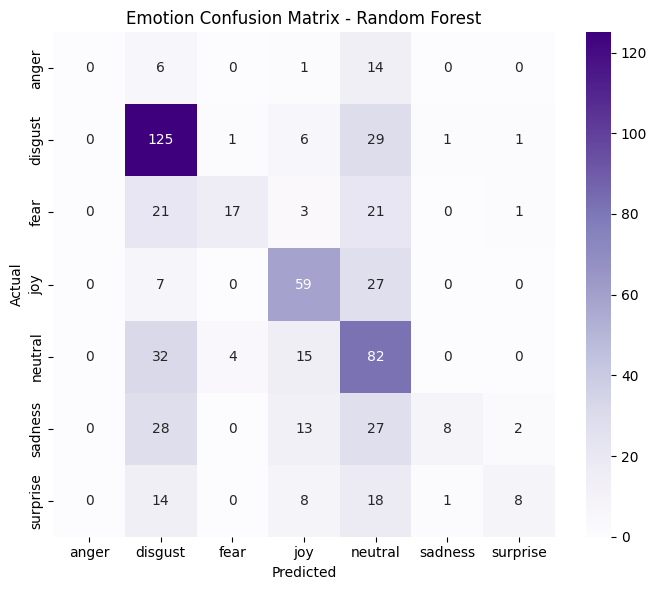


Best accuracy exceeds best macro-F1 by 0.136 - the larger this gap, the more the models are leaning on the majority emotions and ignoring the rare ones.
                 Accuracy  Macro F1  Weighted F1
Random Forest      0.4983    0.3627       0.4545
SVM (LinearSVC)    0.4417    0.3341       0.4207
AdaBoost           0.4350    0.3146       0.3847
KNN                0.3233    0.2048       0.2833


In [25]:
if emotion_ready:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(emo_df))
    ax.bar(x - 0.2, emo_df["Accuracy"], 0.4, label="Accuracy", color="#5D4432")     # two bars per model, side by side
    ax.bar(x + 0.2, emo_df["Macro F1"], 0.4, label="Macro F1", color="#B45309")
    ax.axhline(baseline, ls='--', color="#DC2626", label=f"Majority baseline = {baseline:.3f}")
    ax.set_xticks(x)
    ax.set_xticklabels(emo_df.index, rotation=20, ha="right")
    ax.set_ylabel("Score")
    ax.set_title("Emotion Classification (multi-class) - Accuracy vs Macro F1")
    ax.legend()
    plt.tight_layout()
    plt.show()

    best_emo = emo_df.index[0]      # model with the highest macro-F1, not necessarily highest accuracy
    print(f"=== {best_emo} - per-class breakdown ===")
    print(classification_report(ye_test, emo_predictions[best_emo], zero_division=0))

    labels_sorted = sorted(ye_test.unique())
    cm = confusion_matrix(ye_test, emo_predictions[best_emo], labels=labels_sorted)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",     # 7x7 grid here since there are seven emotion classes, not two
                xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Emotion Confusion Matrix - {best_emo}")
    plt.tight_layout()
    plt.show()

    gap = emo_df["Accuracy"].max() - emo_df["Macro F1"].max()
    print(f"\nBest accuracy exceeds best macro-F1 by {gap:.3f} - the larger this gap, the more the "
          f"models are leaning on the majority emotions and ignoring the rare ones.")

    print(emo_df.round(4).to_string())


## 20. Theoretical Background

A short version of why things turned out this way.

**Why TF-IDF works at all.** TF-IDF upweights words that are common in one review but rare across the rest, and for movie reviews that ends up being evaluative vocabulary like "awful" or "masterpiece." That's the whole reason a representation this simple classifies polarity at ~85%.

**What it costs.** TF-IDF throws away word order, so it's blind to negation ("not good" keeps the token "good," and our stopword removal deletes "not" on top of that, though bigrams in Section 5 are a partial fix), sarcasm, and contrastive structure ("wonderful start, but it collapses" weights both halves equally). DistilBERT (Section 12) doesn't have this problem, because self-attention lets "not" actually modify "good" instead of being counted separately, which is the real reason it competes with models trained directly on this dataset.

**Why the models rank the way they do.** SVM is built for high-dimensional sparse data and scales with support vectors, not dimensions, making it the classic text-classification baseline. Random Forest handles it almost as well by averaging over many trees. KNN is the clear loser: it relies purely on distance, and distance stops being meaningful in high-dimensional sparse spaces (the curse of dimensionality); Section 14 shows a bigger k helps a little but can't fix that. AdaBoost's depth-1 stumps each look at a single term out of 5,000, so it's still underfit at 300 rounds (Section 16); swapping in deeper base trees (gradient boosting) is the usual fix.

**Going from polarity to emotion (Sections 18-19).** Two classes become seven unordered categories, so accuracy stops being trustworthy once the classes are imbalanced, which is why macro-F1 and a majority-class baseline matter more here. The emotion labels are also silver, not gold (machine-generated by another transformer, not human-annotated), so the experiment really measures agreement with that model rather than ground truth.


## 21. Conclusion

- **Preprocessing:** HTML tags stripped, text lowercased, stopwords removed, and lemmatization applied to a random 10,000-review subset of the full IMDB 50K set, mostly to keep training times sane on CPU. DistilBERT skips this pipeline entirely and reads the raw text instead (Section 12).
- **Feature engineering:** review text became a 5,000-term sparse TF-IDF representation, using unigrams and bigrams (`ngram_range=(1, 2)`). Bigrams let short negated phrases like "not good" survive as their own feature instead of collapsing into their positive head word, a partial fix for the bag-of-words limitation covered in Section 20. Section 5 shows how many of the 5,000 slots the bigrams actually took, and Section 8 checks whether any made it into the top-weighted terms.
- **Model selection:** Random Forest, KNN and a linear SVM trained on identical TF-IDF vectors, plus a pretrained `distilbert-base-uncased-finetuned-sst-2-english` scored with no training at all. Section 13 lines up all four on the same reviews. The expected order is DistilBERT and SVM at the top, Random Forest close behind, and KNN clearly last; Section 20 explains why, and the cell below prints whatever order actually came out of this run.
- **Boosting:** `AdaBoostClassifier` (200 depth-1 stumps) joins the same comparison on the same TF-IDF vectors, so it shows up in Sections 6, 7, 10, 11 and 13 too. The point of including it is the bagging-vs-boosting contrast against Random Forest, same base learner, opposite combination strategy, and Section 16's sweep shows it's still improving at 300 rounds, a bias-limited model where Random Forest is variance-limited instead. Section 20 walks through the difference.
- **Evaluation:** accuracy alone doesn't tell the whole story, so the notebook adds ROC-AUC (Section 10) and 5-fold cross-validation with mean +/- std (Section 11). Two caveats: `LinearSVC` has no `probability=True`, so its ROC uses `decision_function` instead (valid, since AUC only depends on ranking), and KNN's `predict_proba` maxes out at k+1 distinct values, which flattens its ROC curve and makes its AUC not really comparable to the others.
- **Tuning:** Section 14 sweeps `n_neighbors` for KNN and Section 15 sweeps `n_estimators` for Random Forest, so the values used back in Section 6 are backed by evidence instead of just picked.
- **Practical takeaway:** the signed SVM coefficients in Section 8 name the exact terms driving each prediction, the strongest interpretability result in the notebook and worth pulling a few specific words into the written report. The sample predictions in Section 17 are the place to look for reviews DistilBERT gets right and the TF-IDF models miss; those rows are the concrete evidence behind the theoretical argument in Section 20.
- **Emotion labels:** Sections 18-19 push the task from two polarities out to seven emotions. Since IMDB has no emotion annotation, labels get generated with `j-hartmann/emotion-english-distilroberta-base` and cached to `emotion_labels.csv`; they're silver labels, so the experiment is really measuring how well bag-of-words models reproduce a transformer's emotion judgments, not human ground truth. The classes are heavily imbalanced, so macro-F1 and a majority-class baseline get reported alongside accuracy, as Section 20 explains.


In [26]:
# Auto-generated summary so the report quotes the numbers this run actually produced.
best = final_results.iloc[0]
print(f"Best model on the shared {len(bert_idx)}-review subset: "
      f"{best['Model']} at {best['Accuracy (same subset)']:.2%}\n")

print("Full test set (2,000 reviews):")
for name in models:
    print(f"  {name:22s} acc={results[name]:.4f}  auc={auc_results[name]:.4f}  "
          f"cv={cv_results[name].mean():.4f} +/- {cv_results[name].std():.4f}")
print(f"  {'DistilBERT (pretrained)':22s} acc={bert_acc:.4f} (on {len(bert_idx)} reviews, zero training)")

spread = max(results.values()) - min(results.values())   # gap between the best and worst trained model
print(f"\nAccuracy spread across the {len(models)} trained models: {spread:.2%}")
print("Largest CV std:", f"{max(cv_results[n].std() for n in models):.4f}",
      "-> any gap smaller than roughly twice this is within split noise.")


Best model on the shared 500-review subset: DistilBERT (pretrained) at 89.20%

Full test set (2,000 reviews):
  Random Forest          acc=0.8380  auc=0.9169  cv=0.8476 +/- 0.0138
  KNN                    acc=0.7145  auc=0.7723  cv=0.7186 +/- 0.0116
  SVM (LinearSVC)        acc=0.8525  auc=0.9326  cv=0.8623 +/- 0.0112
  AdaBoost               acc=0.7950  auc=0.8774  cv=0.8019 +/- 0.0150
  DistilBERT (pretrained) acc=0.8920 (on 500 reviews, zero training)

Accuracy spread across the 4 trained models: 13.80%
Largest CV std: 0.0150 -> any gap smaller than roughly twice this is within split noise.
